<a href="https://colab.research.google.com/github/Rohanrathod7/my-ml-labs/blob/main/20_Introduction_to_Deep_Learning_with_PyTorch/04_Evaluating_and_Improving_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. Evaluating and Improving Models

Training a deep learning model is an art, and to make sure our model is trained correctly, we need to keep track of certain metrics during training, such as the loss or the accuracy. We will learn how to calculate such metrics and how to reduce overfitting.

**Fine-tuning process**   
You are training a model on a new dataset and you think you can use a fine-tuning approach instead of training from scratch (i.e., training from randomly initialized weights).

To fine-tune a model on a new task, you need to follow a certain number of steps that are listed here.


*Fine-tuning is so useful that deep learning engineers rarely train their model from scratch.*

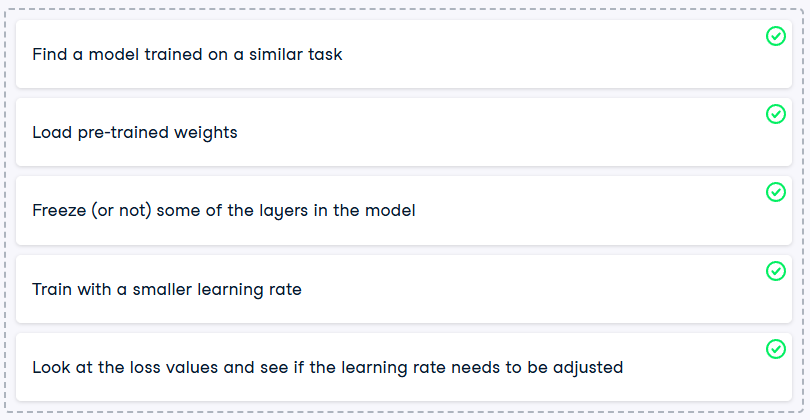

**Freeze layers of a model**  
You are about to fine-tune a model on a new task after loading pre-trained weights. The model contains three linear layers. However, because your dataset is small, you only want to train the last linear layer of this model and freeze the first two linear layers.

The model has already been created and exists under the variable model. You will be using the named_parameters method of the model to list the parameters of the model. Each parameter is described by a name. This name is a string with the following naming convention: x.name where x is the index of the layer.

Remember that a linear layer has two parameters: the weight and the bias.

In [2]:
import torch.nn as nn

# Define a simple model with three linear layers for demonstration purposes
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.linear1 = nn.Linear(10, 20)
        self.linear2 = nn.Linear(20, 30)
        self.linear3 = nn.Linear(30, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        x = self.linear3(x)
        return x

model = SimpleModel()

for name, param in model.named_parameters():
    # Check for first layer's weight
    if name == 'linear1.weight':
        # Freeze this weight
        param.requires_grad = False

    # Check for second layer's weight
    if name == 'linear2.weight':
        # Freeze this weight
        param.requires_grad = False

# You can verify the requires_grad status of the parameters
# for name, param in model.named_parameters():
#     print(f"Parameter: {name}, Requires Grad: {param.requires_grad}")

**Layer initialization**  
The initialization of the weights of a neural network has been the focus of researchers for many years. When training a network, the method used to initialize the weights has a direct impact on the final performance of the network.

As a machine learning practitioner, you should be able to experiment with different initialization strategies. In this exercise, you are creating a small neural network made of two layers and you are deciding to initialize each layer's weights with the uniform method.

In [4]:
layer0 = nn.Linear(16, 32)
layer1 = nn.Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
nn.init.uniform_(layer0.weight)
nn.init.uniform_(layer1.weight)

model = nn.Sequential(layer0, layer1)

# The uniform initialization is one of the many different initialization strategies but they all tend to initialize weights with small values

### Evaluating model performance

**Writing the evaluation loop**  
In this exercise, you will write an evaluation loop to compute validation loss. The evaluation loop follows a similar structure to the training loop but without gradient calculations or weight updates.

model, validationloader, and loss function criterion have already been defined to handle predictions, data loading, and loss calculation.

In [ ]:
import torch

# Set the model to evaluation mode

model.eval()
validation_loss = 0.0

with torch.no_grad():
  for features, labels in validationloader:
      outputs = model(features)
      loss = criterion(outputs, labels)
      # Sum the current loss to the validation_loss variable
      validation_loss += loss.item()

# Calculate the mean loss value
validation_loss_epoch = validation_loss / len(validationloader)
print(validation_loss_epoch)

# Set the model back to training mode
model.train()

In [7]:
# This is a placeholder for your actual validation data loader
# Replace this with the code to load your validation data
validationloader = [] # Replace with your PyTorch DataLoader

**Calculating accuracy using torchmetrics**  
Tracking accuracy during training helps identify the best-performing epoch.

In this exercise, you'll use torchmetrics to calculate accuracy on a facemask dataset with three classes. The plot_errors function will highlight misclassified samples, helping you analyze model errors.

torchmetrics package is already imported. Model outputs are softmax probabilities, and labels are one-hot encoded vectors.



In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 5.0 MB/s eta 0:00:00


In [12]:
import torchmetrics

In [13]:
# Create accuracy metric
metric = torchmetrics.Accuracy(task="multiclass", num_classes=3)
for features, labels in dataloader:
    outputs = model(features)

    # Calculate accuracy over the batch
    metric.update(outputs, labels.argmax(dim=-1))

# Calculate accuracy over the whole epoch
accuracy = metric.compute()
print(f"Accuracy on all data: {accuracy}")

# Reset metric for the next epoch
metric.reset()
plot_errors(model, dataloader)

NameError: name 'dataloader' is not defined

In [14]:
# This is a placeholder for your actual data loader
# Replace this with the code to load your dataset
dataloader = [] # Replace with your PyTorch DataLoader

### Fighting overfitting

**Experimenting with dropout**   
Dropout helps prevent overfitting by randomly setting some output values to zero during training. In this exercise, you'll build a simple neural network with dropout and observe how it behaves in training and evaluation modes.

torch.nn package is preloaded as nn, and features is already defined for you.

In [ ]:
model = nn.Sequential(
    nn.Linear(8, 6),
    nn.Linear(6, 4),
    nn.Dropout(p=0.5))

model.train()
output_train = model(features)

# Forward pass in evaluation mode (Dropout disabled)
model.eval()
output_eval = model(features)

# Print results
print("Output in train mode:", output_train)
print("Output in eval mode:", output_eval)

# Dropout is a powerful tool against overfitting. Real-world models use hundreds of these layers to boost performance on unseen data.

**Understanding overfitting**  
Overfitting is very common in machine learning, where the trend is for bigger and bigger models. As a machine learning practitioner, you will face overfitting in your career. Which three of the following statements about overfitting are True?

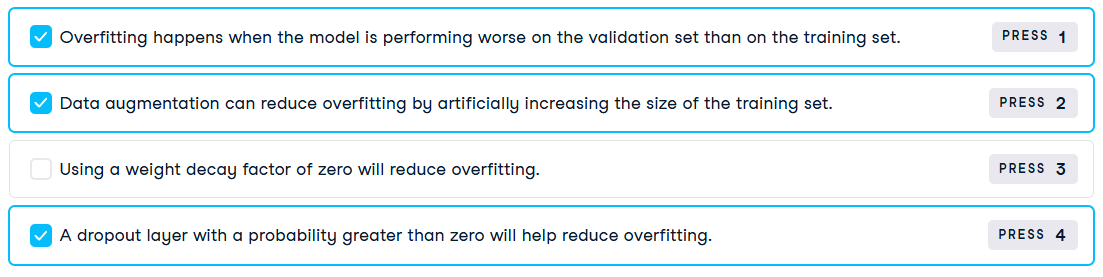

### Improving model performance

**Implementing random search**  
Hyperparameter search is a computationally costly approach to experiment with different hyperparameter values. However, it can lead to performance improvements. In this exercise, you will implement a random search algorithm.

You will randomly sample 10 values of the learning rate and momentum from the uniform distribution. To do so, you will use the np.random.uniform() function.

numpy package has already been imported as np, and a plot_hyperparameter_search() function has been created to visualize your results.

In [ ]:
import numpy as np

values = []
for idx in range(10):
    # Randomly sample a learning rate factor between 2 and 4
    factor = np.random.uniform(2, 4)
    lr = 10 ** -factor

    # Randomly select a momentum between 0.85 and 0.99
    momentum = np.random.uniform(0.85, 0.99)

    values.append((lr, momentum))

plot_hyperparameter_search(values)

# Random search helps refine hyperparameters efficiently. Just remember—keeping track of results is key to understanding what works best for your model.